In [1]:
%env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


In [2]:
# Make sure that the working directory is the project root.
%cd -q ../

In [3]:
import torch
import pickle
import numpy as np
from autoregltl import ted, llama, mamba, dataset
from autoregltl.ltl import trace_check

from tqdm.auto import tqdm
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 192
mpl.rcParams['svg.fonttype'] = 'none'  # Critical: don't convert text to paths
plt.rcParams['pdf.use14corefonts'] = True

device = torch.device('cuda')

In [4]:
redgreen = mpl.colors.LinearSegmentedColormap(
    "redgreen",
    {
        'red': (
            (0.0, 1.0, 1.0),
            (0.15873*3, 1.0, 1.0),
            (0.174603*3, 0.96875, 0.96875),
            (1.0, 0.0, 0.0),
        ),
        'green': (
            (0.0, 0.0, 0.0),
            (0.15873*3, 0.9375, 0.9375),
            (0.174603*3, 1.0, 1.0),
            (1.0, 1.0, 1.0),
        ),
        'blue': (
            (0.0, 0.0, 0.0),
            (1.0, 0.0, 0.0),
        ),
    }
)

In [5]:
def read_eval2da(filename):
    with open(filename, 'rb') as f: evaldict = pickle.load(f)
    #torch.load(filename, map_location=torch.device('cpu'))
    # dict_keys(['correct_matrix', 'count_matrix', 'correct', 'count', 'repeat_count', 'eval_ds', 'all_results'])
        
    count_matrix = evaldict['count_matrix']
    correct_matrix = evaldict['correct_matrix']
    sample_rate = count_matrix / 100.0
    eval_results = torch.where(count_matrix > 0, correct_matrix / count_matrix, 0.0)

    return eval_results, sample_rate, evaldict['correct'], evaldict['count']

Top-3 min eval (sample_rate > 0): 0.8300
Top-3 & 97.47%
Top-5 min eval (sample_rate > 0): 0.8900
Top-5 & 98.32%
Top-10 min eval (sample_rate > 0): 0.9000
Top-10 & 99.03%
Top-25 min eval (sample_rate > 0): 0.9000
Top-25 & 99.54%


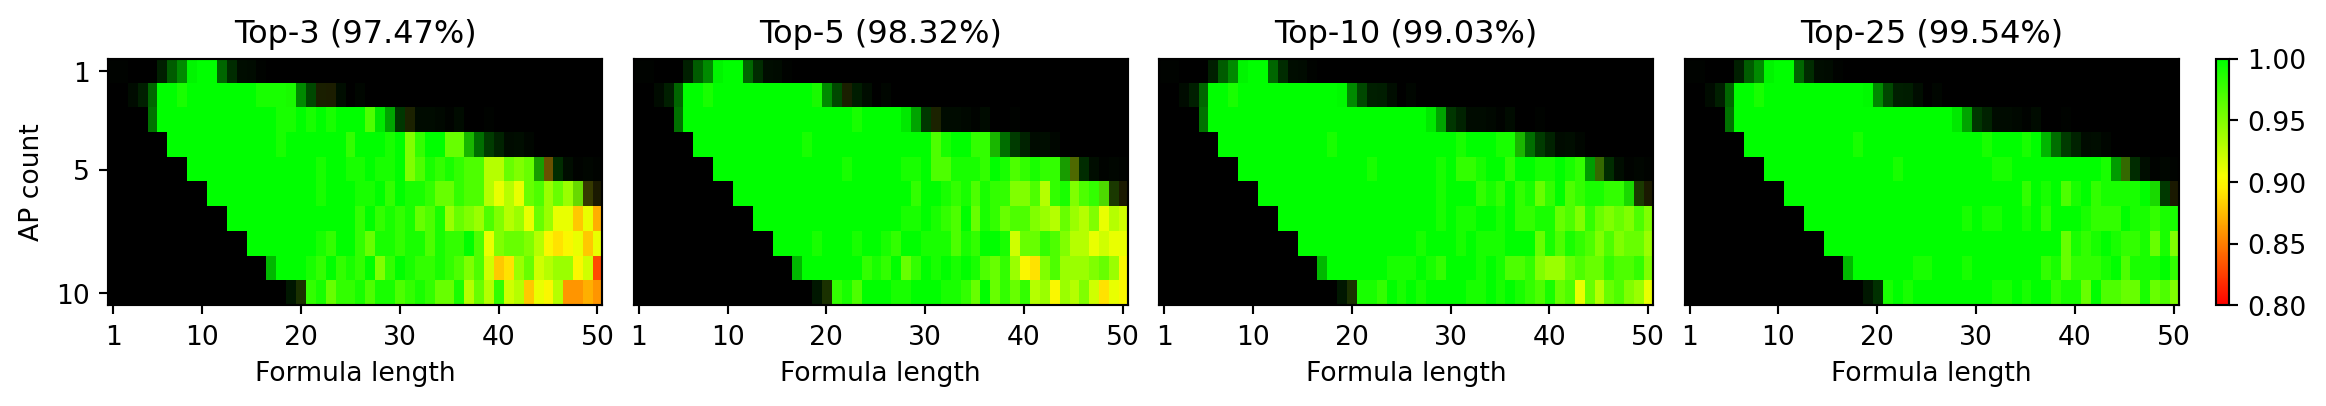

In [12]:
# Plot
models = [
    (f"Top-{i}", f"models-scc/reverse-prop-epat/s1-43/eval2d-top{i}.pkl") for i in [3, 5, 10, 25]
]

fig, axs = plt.subplots(ncols=len(models), nrows=1, figsize=(3*len(models), 2),
                        layout="constrained")

common_kwargs = dict(
    aspect='auto',
)
xticks = [1, 10, 20, 30, 40, 50]
yticks = [1, 5, 10]
vmin = 0.8

for i, (ax, model) in enumerate(zip(axs, models)):
    title, model_path = model
    eval_results, sample_rate, correct, count = read_eval2da(model_path)
    eval_results = eval_results[1:, :]
    sample_rate = sample_rate[1:, :]
    # Print the minimum eval_results where sample_rate > 0
    min_eval = torch.min(eval_results[sample_rate > 0]).item()
    print(f"{title} min eval (sample_rate > 0): {min_eval:.4f}")
    ax.imshow(eval_results, cmap=redgreen, vmin=vmin, vmax=1.0, **common_kwargs)
    # Plotting the modulus array as the 'value' part
    black = torch.zeros(10, 50, 4)
    black[:, :, -1] = 1.0 - sample_rate
    #black[:, :, -1] = torch.where(sample_rate > 0, 0.0, 1.0)
    ax.imshow(black, **common_kwargs)
    
    if i == 0:
        ax.set_ylabel("AP count")
    ax.set_xlabel("Formula length")
    ax.set_xticks([i -1 for i in xticks], xticks)
    ax.set_yticks([i-1 for i in yticks], yticks)
    # # 35 is not actually inclusive
    # ax.add_patch(mpl.patches.Rectangle((-0.4, -0.4), 35-.1, 5-.1, fill=False, edgecolor='white', lw=1.5, linestyle = 'dashed'))
    ax.set_title(f"{title} ({100.0*correct/count:.2f}%)")
    print(f"{title} & {100.0*correct/count:.2f}%")
    
    yticks = []
    full_count = count

fig.colorbar(plt.cm.ScalarMappable(cmap=redgreen, norm=colors.Normalize(vmin=vmin, vmax=1.0)), ax=axs, pad=0.0125)
#fig.tight_layout()

plt.savefig("prop-topn.pdf")